In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [9]:
ts = pd.read_csv('MOD-00605.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T00:21:09Z,1.034,0.117,0.016,0.006,0.011,0.000,2.531,NaN,NaN,NaN,NaN,44.1,-2.7
1,2025-12-31T00:20:20Z,1.267,0.144,0.043,0.000,0.013,0.007,1.739,NaN,NaN,NaN,NaN,44.7,-2.8
2,2025-12-31T00:19:20Z,0.841,0.138,0.013,0.013,0.000,0.000,2.484,NaN,NaN,NaN,NaN,44.6,-2.8
3,2025-12-31T00:18:20Z,0.610,0.108,0.007,0.000,0.000,0.007,3.136,NaN,NaN,NaN,NaN,44.4,-2.9
4,2025-12-29T22:39:14Z,1.078,0.210,0.030,0.003,0.015,0.010,2.935,NaN,NaN,NaN,NaN,44.3,0.5


In [14]:
start = ts['timestamp_local'].min()
print(start)


2025-04-15T08:29:01Z


In [15]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 00:21:09,1.034,0.117,0.016,0.006,0.011,0.000,2.531,NaN,NaN,NaN,NaN,44.1,-2.7
1,2025-12-31 00:20:20,1.267,0.144,0.043,0.000,0.013,0.007,1.739,NaN,NaN,NaN,NaN,44.7,-2.8
2,2025-12-31 00:19:20,0.841,0.138,0.013,0.013,0.000,0.000,2.484,NaN,NaN,NaN,NaN,44.6,-2.8
3,2025-12-31 00:18:20,0.610,0.108,0.007,0.000,0.000,0.007,3.136,NaN,NaN,NaN,NaN,44.4,-2.9
4,2025-12-29 22:39:14,1.078,0.210,0.030,0.003,0.015,0.010,2.935,NaN,NaN,NaN,NaN,44.3,0.5


## Full Timeseries Plot

In [16]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15,5.445985,0.618171,0.194150,0.051937,0.056908,0.039138,9.222980,903.270254,82.117114,2.939256,23.238569,38.935788,17.652589
2025-04-16,0.888326,0.089778,0.030044,0.006868,0.006278,0.003910,0.818583,715.099997,72.910871,2.088635,24.040088,39.476319,10.097431
2025-04-17,2.109576,0.231988,0.085326,0.022472,0.023020,0.015072,2.805024,707.955853,73.735127,2.184025,23.944424,31.381042,13.683750
2025-04-18,5.050991,0.835137,0.388237,0.129137,0.149825,0.104053,9.275146,959.711493,71.189724,3.056883,33.056303,36.582917,15.646736
2025-04-19,11.749495,1.144806,0.495215,0.168232,0.219336,0.157817,26.084861,1023.710228,81.725238,2.725842,23.780452,48.827431,22.994236


In [17]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15,5.445985,0.618171,0.194150,0.051937,0.056908,0.039138,9.222980,903.270254,82.117114,2.939256,23.238569,38.935788,17.652589,8.209136
2025-04-16,0.888326,0.089778,0.030044,0.006868,0.006278,0.003910,0.818583,715.099997,72.910871,2.088635,24.040088,39.476319,10.097431,2.813937
2025-04-17,2.109576,0.231988,0.085326,0.022472,0.023020,0.015072,2.805024,707.955853,73.735127,2.184025,23.944424,31.381042,13.683750,4.589647
2025-04-18,5.050991,0.835137,0.388237,0.129137,0.149825,0.104053,9.275146,959.711493,71.189724,3.056883,33.056303,36.582917,15.646736,8.209358
2025-04-19,11.749495,1.144806,0.495215,0.168232,0.219336,0.157817,26.084861,1023.710228,81.725238,2.725842,23.780452,48.827431,22.994236,17.830587


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5787/685588872.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


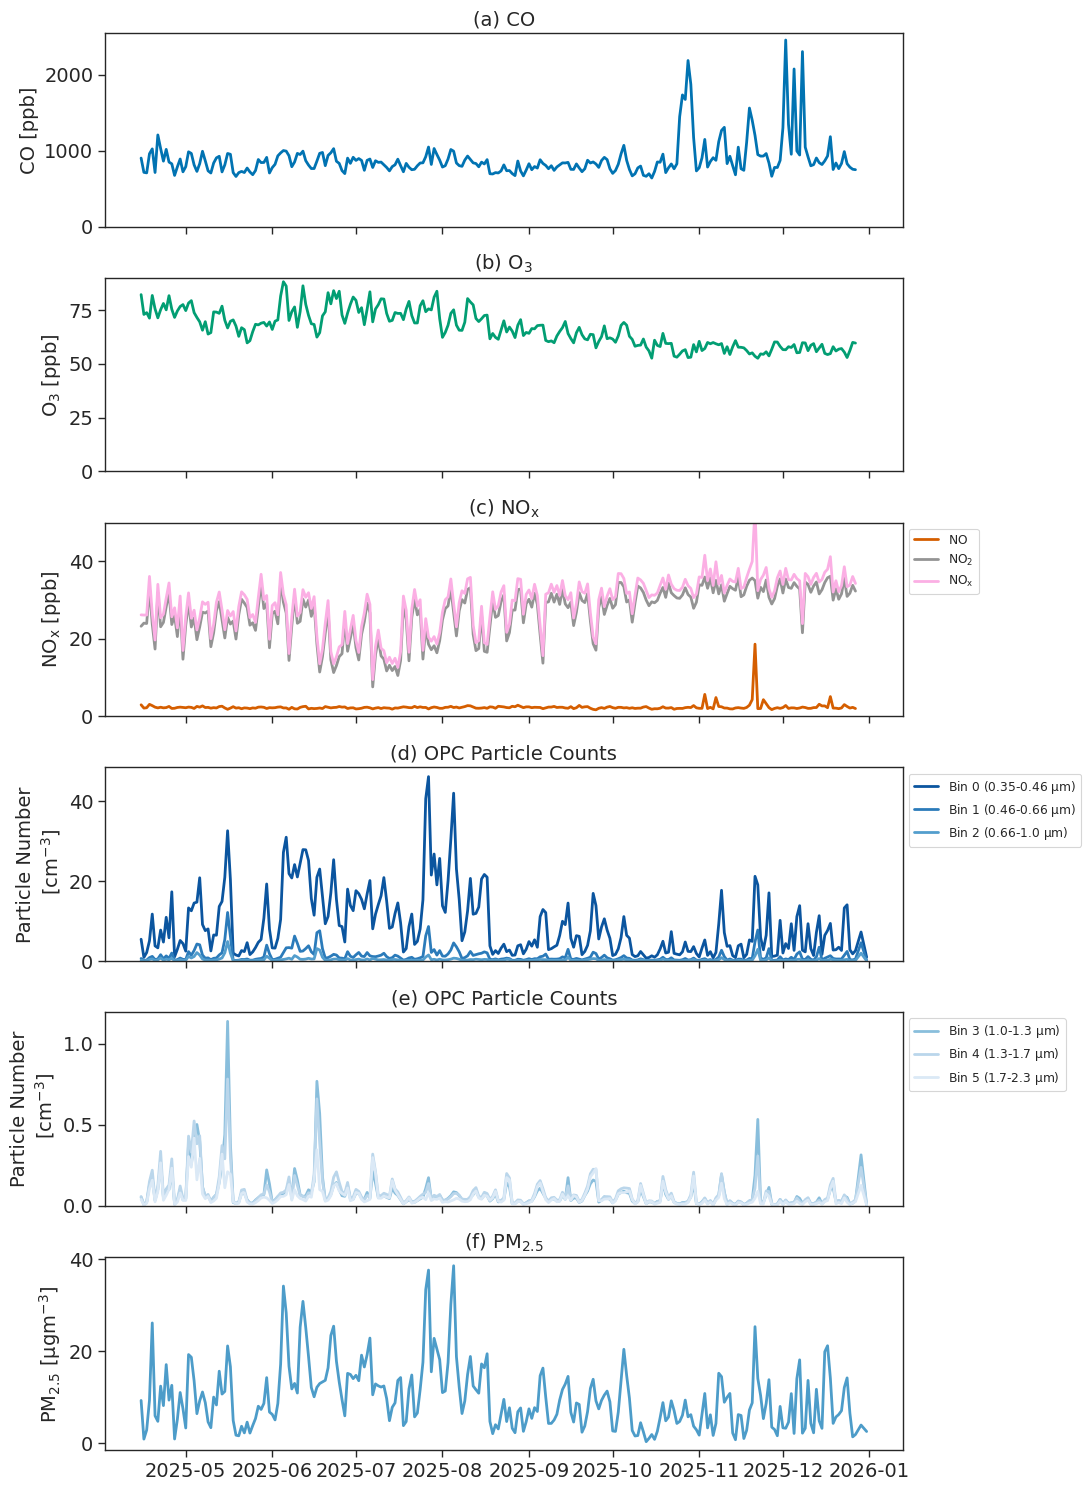

In [18]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

fig.savefig('timeseries_MOD-00605.png')

## Dirunal Plots

In [19]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-04-15 08:00:00,5.949083,0.567000,0.229000,0.060500,0.057083,0.031333,10.555250,NaN,NaN,NaN,NaN,35.316667,22.825000
2025-04-15 09:00:00,20.892059,2.401647,0.639765,0.172059,0.165765,0.105647,25.088765,NaN,NaN,NaN,NaN,53.047059,18.876471
2025-04-15 10:00:00,20.735433,2.228267,0.594000,0.144683,0.142133,0.093300,28.141067,1602.056500,92.368938,2.259625,41.171250,56.213333,18.343333
2025-04-15 11:00:00,21.478500,2.429367,0.652283,0.156467,0.148183,0.096333,31.259717,1550.779800,86.117100,4.057733,42.502233,57.323333,18.236667
2025-04-15 12:00:00,9.352450,1.026733,0.343767,0.091400,0.100050,0.062550,16.984633,1353.582883,88.561250,5.954117,16.947100,41.221667,20.825000


In [20]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-04-15 08:00:00,5.949083,0.567000,0.229000,0.060500,0.057083,0.031333,10.555250,NaN,NaN,NaN,NaN,35.316667,22.825000,7.245315
2025-04-15 09:00:00,20.892059,2.401647,0.639765,0.172059,0.165765,0.105647,25.088765,NaN,NaN,NaN,NaN,53.047059,18.876471,11.804405
2025-04-15 10:00:00,20.735433,2.228267,0.594000,0.144683,0.142133,0.093300,28.141067,1602.056500,92.368938,2.259625,41.171250,56.213333,18.343333,12.763325
2025-04-15 11:00:00,21.478500,2.429367,0.652283,0.156467,0.148183,0.096333,31.259717,1550.779800,86.117100,4.057733,42.502233,57.323333,18.236667,13.713989
2025-04-15 12:00:00,9.352450,1.026733,0.343767,0.091400,0.100050,0.062550,16.984633,1353.582883,88.561250,5.954117,16.947100,41.221667,20.825000,9.202991


In [21]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-04-15 08:00:00,5.949083,0.567000,0.229000,0.060500,0.057083,0.031333,10.555250,NaN,NaN,NaN,NaN,35.316667,22.825000,7.245315,8
2025-04-15 09:00:00,20.892059,2.401647,0.639765,0.172059,0.165765,0.105647,25.088765,NaN,NaN,NaN,NaN,53.047059,18.876471,11.804405,9
2025-04-15 10:00:00,20.735433,2.228267,0.594000,0.144683,0.142133,0.093300,28.141067,1602.056500,92.368938,2.259625,41.171250,56.213333,18.343333,12.763325,10
2025-04-15 11:00:00,21.478500,2.429367,0.652283,0.156467,0.148183,0.096333,31.259717,1550.779800,86.117100,4.057733,42.502233,57.323333,18.236667,13.713989,11
2025-04-15 12:00:00,9.352450,1.026733,0.343767,0.091400,0.100050,0.062550,16.984633,1353.582883,88.561250,5.954117,16.947100,41.221667,20.825000,9.202991,12


In [22]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,9.247568,1.517506,0.461258,0.099771,0.098211,0.065712,9.973380,886.266401,65.409787,2.439589,28.727510,62.320728,17.327034,7.445116
01:00,9.171543,1.518557,0.468397,0.102581,0.100444,0.066369,9.427588,859.403132,64.744745,2.286782,28.915980,64.020557,17.018110,7.307820
02:00,9.058162,1.403148,0.412043,0.089992,0.091053,0.062693,9.092558,858.872608,64.121834,2.324669,28.692019,65.201528,16.674867,7.219162
03:00,9.245321,1.456384,0.427199,0.093574,0.094428,0.065173,9.023574,867.518785,63.391935,2.291564,28.312156,66.537938,16.432658,7.218568
04:00,9.338533,1.520180,0.446805,0.097142,0.095975,0.065502,8.722415,870.946206,62.719557,2.322382,28.286898,67.679993,16.131485,7.141174
05:00,9.453856,1.529688,0.473315,0.106642,0.104087,0.067541,8.862217,885.181572,61.957124,2.301635,28.623826,68.684052,15.904435,7.195580
06:00,9.460996,1.511233,0.477164,0.112753,0.111749,0.071187,9.221346,910.130266,61.418253,2.214698,29.010831,68.657463,15.741847,7.293833
07:00,9.571828,1.521790,0.463185,0.106458,0.111407,0.077371,9.390019,936.788500,61.649524,2.448387,27.481263,66.915339,16.342091,7.332298
08:00,9.269407,1.302708,0.374741,0.087000,0.095341,0.068697,9.876803,920.719395,61.836333,2.716843,23.189304,60.227078,18.319774,7.415726


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5787/452469904.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_5787/452469904.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r

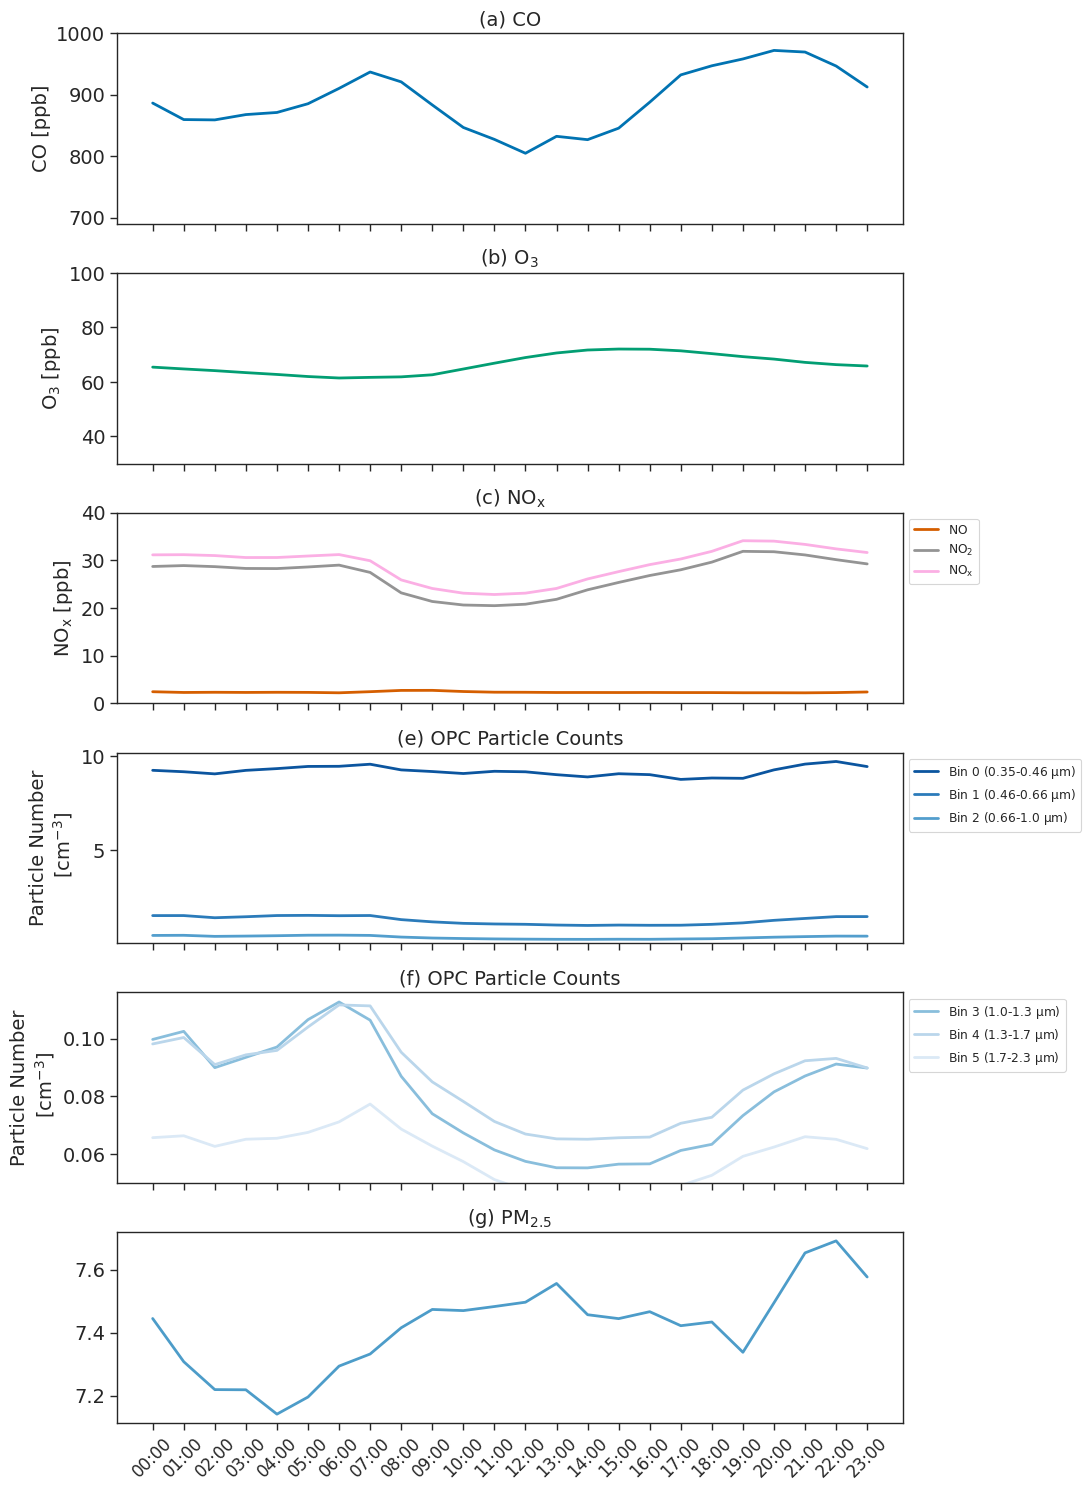

In [24]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 1000)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 100)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 40)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)


# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('dirunal_MOD-00605_allfeatures.png')

## Diurnal by Season

In [25]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [26]:
ts_hour = ts_hour.reset_index()

In [27]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-04-15 08:00:00,5.949083,0.567000,0.229000,0.060500,0.057083,0.031333,10.555250,NaN,NaN,NaN,NaN,35.316667,22.825000,7.245315,8,Spring
1,2025-04-15 09:00:00,20.892059,2.401647,0.639765,0.172059,0.165765,0.105647,25.088765,NaN,NaN,NaN,NaN,53.047059,18.876471,11.804405,9,Spring
2,2025-04-15 10:00:00,20.735433,2.228267,0.594000,0.144683,0.142133,0.093300,28.141067,1602.056500,92.368938,2.259625,41.171250,56.213333,18.343333,12.763325,10,Spring
3,2025-04-15 11:00:00,21.478500,2.429367,0.652283,0.156467,0.148183,0.096333,31.259717,1550.779800,86.117100,4.057733,42.502233,57.323333,18.236667,13.713989,11,Spring
4,2025-04-15 12:00:00,9.352450,1.026733,0.343767,0.091400,0.100050,0.062550,16.984633,1353.582883,88.561250,5.954117,16.947100,41.221667,20.825000,9.202991,12,Spring


In [28]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                               
Autumn 0     4.874166  0.837450  0.299923  0.069581  0.075843  0.055143   
       1     5.041435  0.785312  0.258893  0.057812  0.064505  0.050241   
       2     5.174834  0.780897  0.258578  0.058452  0.064724  0.051237   
       3     5.505961  0.814982  0.266454  0.060164  0.067323  0.053204   
       4     5.794474  0.928828  0.309745  0.069047  0.072152  0.054000   
...               ...       ...       ...       ...       ...       ...   
Winter 19    5.634513  0.843950  0.202976  0.034840  0.037027  0.024260   
       20    5.923228  0.889729  0.206294  0.035642  0.036957  0.023512   
       21    5.773210  0.873092  0.203271  0.035253  0.038924  0.026706   
       22    5.982388  0.951850  0.215894  0.038184  0.042047  0.028507   
       23    6.834780  1.192416  0.256678  0.042935  0.046806  0.033795   

                 pm25           co         o3        no        no2         rh  \
Season Hour                                                                     
Autumn 0     6.927259   894.000757  60.092716  2.915958  31.377629  61.411610   
       1     6.749100   876.098432  59.512288  2.551648  32.019786  63.594527   
       2     6.605379   879.798915  58.943662  2.751921  32.045150  65.037094   
       3     6.755045   924.728341  58.333251  2.696885  32.164131  66.815258   
       4     6.525847   909.366985  57.975093  2.830787  32.134671  68.029412   
...               ...          ...        ...       ...        ...        ...   
Winter 19    8.241938  1110.735770  57.408876  2.196447  33.978593  55.569012   
       20    8.705264  1069.050666  57.183564  2.255626  33.548279  55.960185   
       21    8.528255  1000.717199  56.935423  2.247548  33.230542  55.589359   
       22    8.545712   964.365656  56.998802  2.171103  33.508339  56.768735   
       23    9.014892   879.817538  56.933893  2.258499  33.287853  58.789487   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.551951  6.426799  
       1     15.156838  6.406342  
       2     14.779062  6.379246  
       3     14.528547  6.453997  
       4     14.237078  6.400262  
...                ...       ...  
Winter 19     2.440679  6.022788  
       20     2.192593  6.157843  
       21     2.135897  6.093360  
       22     1.871759  6.113660  
       23     1.659423  6.291357  

[96 rows x 14 columns]

In [29]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,4.874166,0.837450,0.299923,0.069581,0.075843,0.055143,6.927259,894.000757,60.092716,2.915958,31.377629,61.411610,15.551951,6.426799
1,Autumn,1,5.041435,0.785312,0.258893,0.057812,0.064505,0.050241,6.749100,876.098432,59.512288,2.551648,32.019786,63.594527,15.156838,6.406342
2,Autumn,2,5.174834,0.780897,0.258578,0.058452,0.064724,0.051237,6.605379,879.798915,58.943662,2.751921,32.045150,65.037094,14.779062,6.379246
3,Autumn,3,5.505961,0.814982,0.266454,0.060164,0.067323,0.053204,6.755045,924.728341,58.333251,2.696885,32.164131,66.815258,14.528547,6.453997
4,Autumn,4,5.794474,0.928828,0.309745,0.069047,0.072152,0.054000,6.525847,909.366985,57.975093,2.830787,32.134671,68.029412,14.237078,6.400262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,5.634513,0.843950,0.202976,0.034840,0.037027,0.024260,8.241938,1110.735770,57.408876,2.196447,33.978593,55.569012,2.440679,6.022788
92,Winter,20,5.923228,0.889729,0.206294,0.035642,0.036957,0.023512,8.705264,1069.050666,57.183564,2.255626,33.548279,55.960185,2.192593,6.157843
93,Winter,21,5.773210,0.873092,0.203271,0.035253,0.038924,0.026706,8.528255,1000.717199,56.935423,2.247548,33.230542,55.589359,2.135897,6.093360
94,Winter,22,5.982388,0.951850,0.215894,0.038184,0.042047,0.028507,8.545712,964.365656,56.998802,2.171103,33.508339,56.768735,1.871759,6.113660


In [30]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [31]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,4.874166,0.837450,0.299923,0.069581,0.075843,0.055143,6.927259,894.000757,60.092716,2.915958,31.377629,61.411610,15.551951,6.426799
01:00,Autumn,1,5.041435,0.785312,0.258893,0.057812,0.064505,0.050241,6.749100,876.098432,59.512288,2.551648,32.019786,63.594527,15.156838,6.406342
02:00,Autumn,2,5.174834,0.780897,0.258578,0.058452,0.064724,0.051237,6.605379,879.798915,58.943662,2.751921,32.045150,65.037094,14.779062,6.379246
03:00,Autumn,3,5.505961,0.814982,0.266454,0.060164,0.067323,0.053204,6.755045,924.728341,58.333251,2.696885,32.164131,66.815258,14.528547,6.453997
04:00,Autumn,4,5.794474,0.928828,0.309745,0.069047,0.072152,0.054000,6.525847,909.366985,57.975093,2.830787,32.134671,68.029412,14.237078,6.400262
05:00,Autumn,5,6.286664,1.082958,0.367396,0.078485,0.074907,0.052695,6.977643,939.151244,57.296946,2.765529,32.220255,69.130725,14.010118,6.549981
06:00,Autumn,6,6.580131,1.130885,0.394204,0.085688,0.079157,0.051565,7.495319,961.608033,56.592881,2.486130,32.803033,69.414133,13.612426,6.691166
07:00,Autumn,7,6.391428,0.990239,0.306950,0.065574,0.067556,0.049254,7.032122,952.615585,56.837309,2.942681,32.155330,68.038617,13.942140,6.536606
08:00,Autumn,8,5.802220,0.829852,0.268616,0.061180,0.067147,0.049386,7.436676,941.189551,56.940020,2.831515,27.799119,61.947689,15.571989,6.592474
09:00,Autumn,9,5.473675,0.726517,0.237194,0.055284,0.064106,0.048416,7.919625,927.595430,57.330336,2.915838,26.250074,56.092614,17.342424,6.684392


In [32]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_5787/187967698.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipykernel_5787/187967698.py:41: SyntaxWarning: invalid escape sequence '\m'


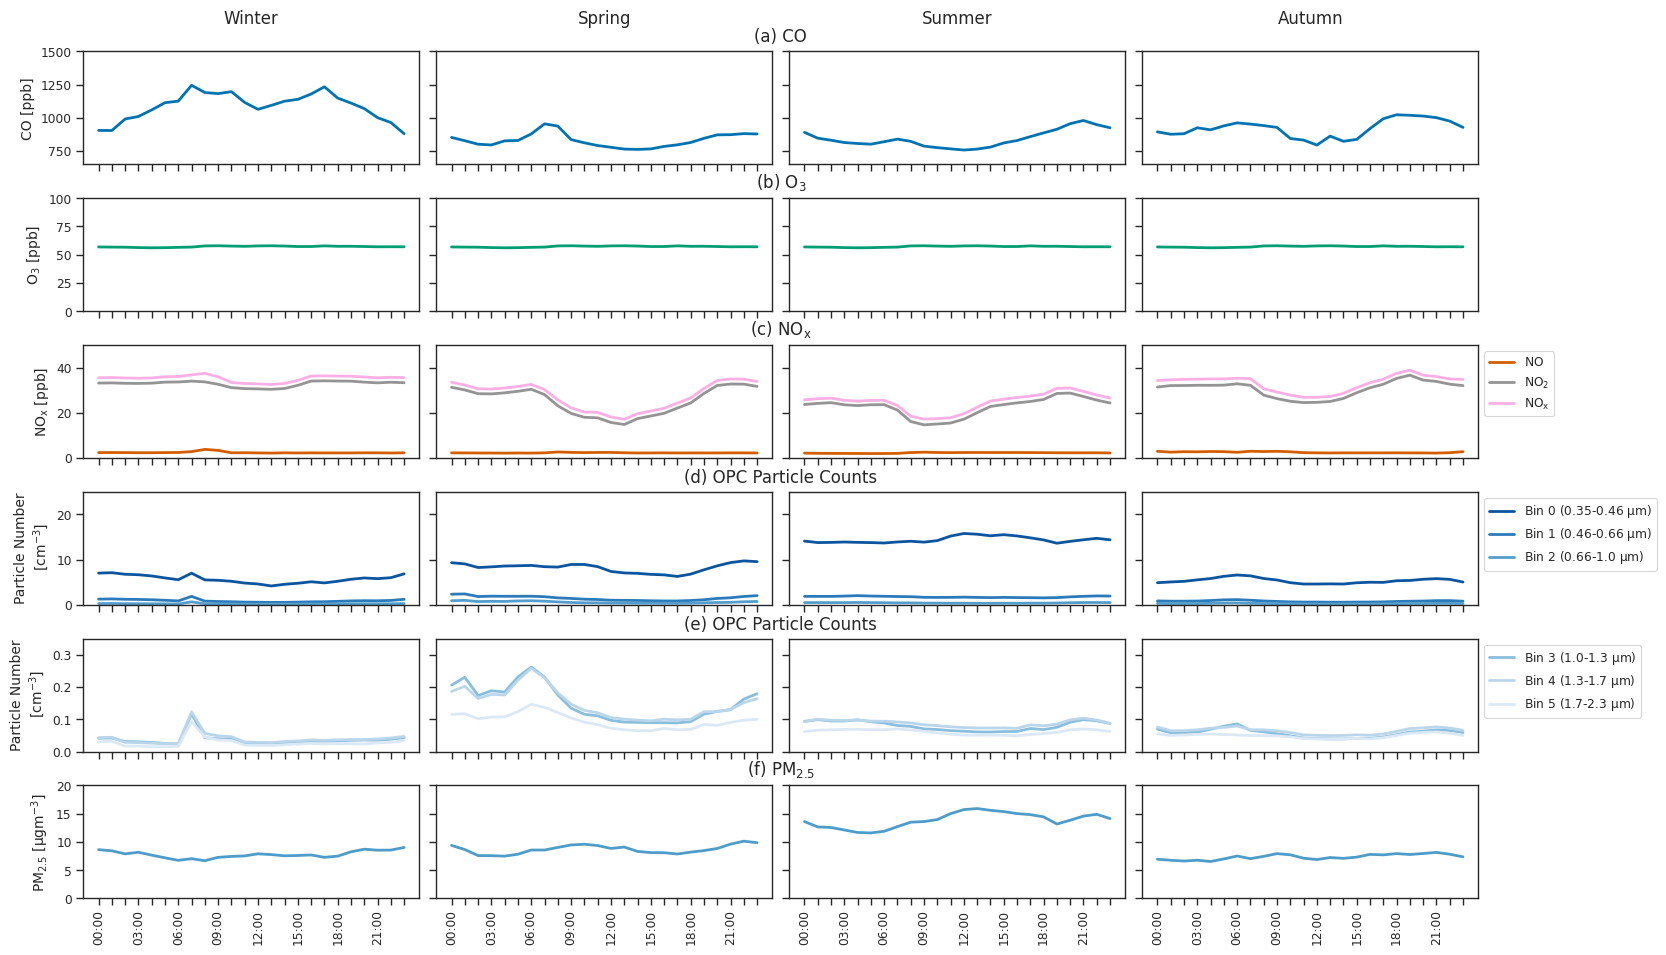

In [33]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 1500)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 100)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('diurnal_by_season_MOD-00605.png')